# BTC/USDT — Moving Average Crossover Backtest Grid

**Signal logic:** When the **fast MA crosses above** the slow MA → go long (buy). When it crosses back below → exit to cash.

## MA Types Tested
| Type | Description |
|------|-------------|
| SMA | Simple Moving Average — equal weight to all periods |
| EMA | Exponential MA — exponentially decaying weight, more responsive |
| WMA | Weighted MA — linearly increasing weight, recent bars heavier |
| VWMA | Volume-Weighted MA — weights by traded volume |
| HMA | Hull MA — low lag, uses WMA of 2×WMA(n/2) − WMA(n) |
| DEMA | Double EMA — 2×EMA − EMA(EMA), reduces lag |
| TEMA | Triple EMA — 3×EMA − 3×EMA² + EMA³, very low lag |

## Grid
- **Fast MAs (15):** SMA/EMA/WMA/VWMA/HMA/DEMA/TEMA with short periods (5–20)
- **Slow MAs (12):** SMA/EMA/WMA/VWMA/HMA/DEMA with long periods (50–200)
- **Total combinations:** 180 backtests

## Output Heatmaps
1. Total Portfolio Return (%) — as of today
2. Maximum Drawdown (%)
3. Sharpe Ratio
4. Number of Trades (whipsaw indicator)

In [1]:
# pip install yfinance pandas numpy matplotlib seaborn
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
print('Libraries loaded.')

Libraries loaded.


In [2]:
def fetch_btc(start='2018-01-01', end=None):
    if end is None:
        end = datetime.today().strftime('%Y-%m-%d')
    raw = yf.Ticker('BTC-USD').history(start=start, end=end, interval='1d')
    raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']].reset_index()
    raw.rename(columns={
        'Date': 'date', 'Open': 'open', 'High': 'high',
        'Low': 'low', 'Close': 'close', 'Volume': 'volume'
    }, inplace=True)
    raw['date'] = raw['date'].dt.tz_localize(None).dt.normalize()
    return raw.sort_values('date').reset_index(drop=True)

data = fetch_btc(start='2018-01-01')
print(f'BTC/USD: {len(data)} rows  |  {data.date.min().date()} → {data.date.max().date()}')

# Date-indexed series for MA computation and backtesting
dates   = pd.to_datetime(data['date'])
price_s = pd.Series(data['close'].values,  index=dates, name='close')
vol_s   = pd.Series(data['volume'].values, index=dates, name='volume')

data.tail(3)

BTC/USD: 3041 rows  |  2018-01-01 → 2026-04-29


,date,open,high,low,close,volume
3038,2026-04-27,78661.015625,79488.171875,76481.343750,77366.625000,38135631927
3039,2026-04-28,77368.117188,77483.867188,75673.601562,76350.671875,32056900880
3040,2026-04-29,76350.687500,77884.968750,74958.570312,75776.132812,41460907886


In [3]:
def sma(price, period):
    return price.rolling(period).mean()

def ema(price, period):
    return price.ewm(span=period, adjust=False).mean()

def wma(price, period):
    w = np.arange(1, period + 1, dtype=float)
    return price.rolling(period).apply(lambda x: (x * w).sum() / w.sum(), raw=True)

def vwma(price, volume, period):
    return (price * volume).rolling(period).sum() / volume.rolling(period).sum()

def hma(price, period):
    half_p = max(2, period // 2)
    sqrt_p = max(2, int(np.sqrt(period)))
    return wma(2 * wma(price, half_p) - wma(price, period), sqrt_p)

def dema(price, period):
    e1 = price.ewm(span=period, adjust=False).mean()
    return 2 * e1 - e1.ewm(span=period, adjust=False).mean()

def tema(price, period):
    e1 = price.ewm(span=period, adjust=False).mean()
    e2 = e1.ewm(span=period, adjust=False).mean()
    e3 = e2.ewm(span=period, adjust=False).mean()
    return 3 * e1 - 3 * e2 + e3

def compute_ma(price, volume, ma_type, period):
    if ma_type == 'SMA':  return sma(price, period)
    if ma_type == 'EMA':  return ema(price, period)
    if ma_type == 'WMA':  return wma(price, period)
    if ma_type == 'VWMA': return vwma(price, volume, period)
    if ma_type == 'HMA':  return hma(price, period)
    if ma_type == 'DEMA': return dema(price, period)
    if ma_type == 'TEMA': return tema(price, period)
    raise ValueError(f'Unknown MA type: {ma_type}')

print('MA functions defined: SMA · EMA · WMA · VWMA · HMA · DEMA · TEMA')

MA functions defined: SMA · EMA · WMA · VWMA · HMA · DEMA · TEMA


Grid: 15 fast × 12 slow = 180 combos
Precomputing MA series (WMA/HMA may take a moment)...
Done: 27 MA series in 0.15s


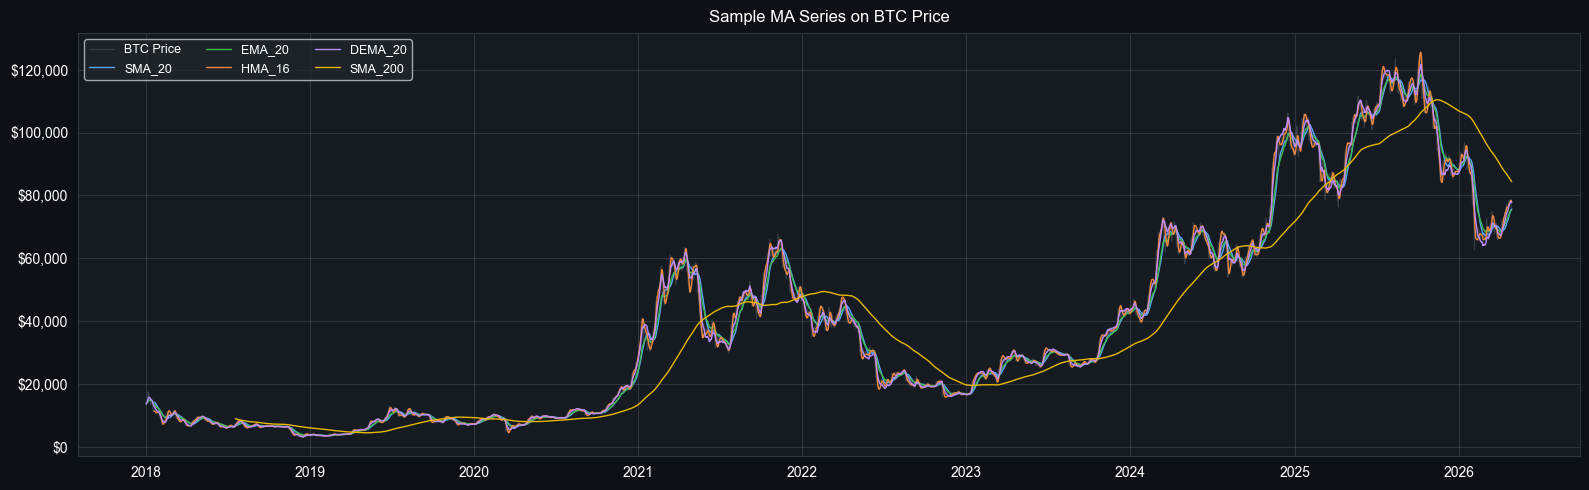

In [4]:
# ── Define the crossover grid ───────────────────────────────────────────────
FAST_MAS = [
    ('SMA',   5), ('SMA',  10), ('SMA',  20),
    ('EMA',   5), ('EMA',  10), ('EMA',  20),
    ('WMA',  10), ('WMA',  20),
    ('VWMA', 10), ('VWMA', 20),
    ('HMA',   9), ('HMA',  16),
    ('DEMA', 10), ('DEMA', 20),
    ('TEMA', 10),
]  # 15 fast MAs

SLOW_MAS = [
    ('SMA',  50), ('SMA', 100), ('SMA', 200),
    ('EMA',  50), ('EMA', 100), ('EMA', 200),
    ('WMA',  50), ('WMA', 100),
    ('VWMA', 50),
    ('HMA',  50), ('HMA', 100),
    ('DEMA', 50),
]  # 12 slow MAs

fast_labels = [f'{t}_{p}' for t, p in FAST_MAS]
slow_labels = [f'{t}_{p}' for t, p in SLOW_MAS]
print(f'Grid: {len(fast_labels)} fast × {len(slow_labels)} slow = {len(fast_labels)*len(slow_labels)} combos')

# ── Precompute all unique MA series ─────────────────────────────────────────
print('Precomputing MA series (WMA/HMA may take a moment)...')
t0 = time.time()

mas = {}
for ma_type, period in list(set(FAST_MAS + SLOW_MAS)):
    key = f'{ma_type}_{period}'
    if key not in mas:
        mas[key] = compute_ma(price_s, vol_s, ma_type, period)

print(f'Done: {len(mas)} MA series in {time.time()-t0:.2f}s')

# Quick visual check of a few MAs
fig, ax = plt.subplots(figsize=(16, 5), facecolor='#0d1117')
ax.set_facecolor('#161b22')
ax.plot(price_s.index, price_s.values, color='#444d56', lw=0.8, alpha=0.7, label='BTC Price')
for label, color in [('SMA_20','#58a6ff'),('EMA_20','#3fb950'),('HMA_16','#f0883e'),
                     ('DEMA_20','#bc8cff'),('SMA_200','#e6b800')]:
    ax.plot(price_s.index, mas[label].values, lw=1.0, label=label, color=color)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Sample MA Series on BTC Price', color='white', pad=8)
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=9, ncol=3)
ax.tick_params(colors='white')
ax.grid(alpha=0.12)
for spine in ax.spines.values(): spine.set_color('#30363d')
plt.tight_layout()
plt.show()

In [5]:
def backtest_crossover(price, fast_ma, slow_ma, fee=0.001, capital=10_000):
    # Only start after both MAs have warmed up
    valid = fast_ma.notna() & slow_ma.notna()
    if valid.sum() < 50:
        return None

    p = price[valid].values
    f = fast_ma[valid].values
    s = slow_ma[valid].values
    idx = price[valid].index

    # Position: 1 = long BTC, 0 = cash
    pos = (f > s).astype(int)
    # Transitions: +1 = entry (crossover up), -1 = exit (crossover down)
    chg = np.diff(pos, prepend=pos[0])

    cash = float(capital)
    btc  = 0.0
    pv   = np.empty(len(p))
    n_trades = 0

    for i in range(len(p)):
        if chg[i] == 1 and cash > 0:      # buy on crossover up
            btc  = cash * (1 - fee) / p[i]
            cash = 0.0
            n_trades += 1
        elif chg[i] == -1 and btc > 0:    # sell on crossover down
            cash = btc * p[i] * (1 - fee)
            btc  = 0.0
            n_trades += 1
        pv[i] = cash + btc * p[i]

    pv_s  = pd.Series(pv, index=idx)
    final = pv_s.iloc[-1]
    total = (final - capital) / capital * 100

    dr    = pv_s.pct_change().dropna()
    std   = dr.std()
    rf    = (1.04 ** (1/365.25)) - 1
    exc   = dr - rf
    sharpe  = (exc.mean() / std) * np.sqrt(365.25) if std > 0 else 0.0
    down    = dr[dr < rf]
    sortino = (exc.mean() / down.std()) * np.sqrt(365.25) if len(down) > 1 and down.std() > 0 else 0.0

    roll_max = pv_s.cummax()
    max_dd   = ((pv_s - roll_max) / roll_max * 100).min()

    return {
        'total_return': round(total,   1),
        'max_drawdown': round(max_dd,  1),
        'sharpe':       round(sharpe,  3),
        'sortino':      round(sortino, 3),
        'n_trades':     n_trades,
        'final_value':  round(final,   2),
        'pv':           pv_s,
    }

print('Backtest engine ready.')

Backtest engine ready.


In [6]:
print(f'Running {len(fast_labels) * len(slow_labels)} backtests...')
t0 = time.time()

results = {}
for fk in fast_labels:
    for sk in slow_labels:
        res = backtest_crossover(price_s, mas[fk], mas[sk])
        if res is not None:
            results[(fk, sk)] = res

elapsed = time.time() - t0
print(f'Done: {len(results)} backtests in {elapsed:.2f}s  ({elapsed/len(results)*1000:.1f}ms each)')

# BTC buy & hold reference
BH_CAPITAL = 10_000
bh_btc  = BH_CAPITAL * (1 - 0.001) / price_s.iloc[0]
bh_final = bh_btc * price_s.iloc[-1]
bh_ret  = (bh_final - BH_CAPITAL) / BH_CAPITAL * 100
bh_pv   = pd.Series(BH_CAPITAL * price_s.values / price_s.values[0], index=price_s.index)

all_returns = [r['total_return'] for r in results.values()]
print(f'\nBTC Buy & Hold:  {bh_ret:.1f}%')
print(f'Best strategy:   {max(all_returns):.1f}%')
print(f'Median strategy: {np.median(all_returns):.1f}%')
print(f'Worst strategy:  {min(all_returns):.1f}%')
print(f'Beat B&H count:  {sum(r > bh_ret for r in all_returns)} / {len(all_returns)}')

Running 180 backtests...
Done: 180 backtests in 0.43s  (2.4ms each)

BTC Buy & Hold:  454.3%
Best strategy:   2778.3%
Median strategy: 1024.9%
Worst strategy:  -19.7%
Beat B&H count:  163 / 180


In [7]:
rows = []
for (fk, sk), r in results.items():
    rows.append({
        'Fast MA':          fk,
        'Slow MA':          sk,
        'Total Return (%)': r['total_return'],
        'vs B&H (pp)':      round(r['total_return'] - bh_ret, 1),
        'Max DD (%)':       r['max_drawdown'],
        'Sharpe':           r['sharpe'],
        'Sortino':          r['sortino'],
        'Trades':           r['n_trades'],
        'Final ($)':        f'${r["final_value"]:,.0f}',
    })

df_all = pd.DataFrame(rows).sort_values('Total Return (%)', ascending=False).reset_index(drop=True)

print('TOP 15 STRATEGIES')
display(df_all.head(15))
print()
print('BOTTOM 15 STRATEGIES')
display(df_all.tail(15).reset_index(drop=True))

TOP 15 STRATEGIES


,Fast MA,Slow MA,Total Return (%),vs B&H (pp),Max DD (%),Sharpe,Sortino,Trades,Final ($)
0,SMA_5,SMA_100,2778.3,2324.0,-41.3,1.089,1.589,43,"$287,832"
1,DEMA_10,SMA_100,2777.7,2323.4,-40.6,1.088,1.592,43,"$287,773"
2,WMA_10,SMA_100,2770.9,2316.6,-41.5,1.088,1.588,39,"$287,094"
3,HMA_16,SMA_100,2670.3,2216.0,-50.1,1.071,1.552,51,"$277,034"
4,EMA_5,SMA_100,2650.5,2196.2,-42.4,1.075,1.569,45,"$275,050"
5,EMA_10,SMA_100,2586.4,2132.1,-38.8,1.074,1.574,37,"$268,643"
6,TEMA_10,SMA_100,2218.3,1764.0,-42.1,1.026,1.491,61,"$231,829"
7,DEMA_10,WMA_50,2211.5,1757.2,-63.3,1.016,1.467,101,"$231,147"
8,EMA_5,WMA_50,2100.5,1646.2,-63.3,1.002,1.450,109,"$220,052"
9,DEMA_20,SMA_100,2061.9,1607.6,-43.7,1.007,1.470,39,"$216,194"



BOTTOM 15 STRATEGIES


,Fast MA,Slow MA,Total Return (%),vs B&H (pp),Max DD (%),Sharpe,Sortino,Trades,Final ($)
0,VWMA_10,HMA_50,419.4,-34.9,-70.8,0.591,0.851,154,"$51,936"
1,WMA_20,SMA_50,417.6,-36.7,-63.0,0.589,0.840,71,"$51,760"
2,SMA_10,DEMA_50,412.0,-42.3,-60.1,0.578,0.812,101,"$51,195"
3,SMA_5,HMA_50,405.8,-48.5,-63.5,0.580,0.863,208,"$50,580"
4,EMA_10,HMA_50,378.7,-75.6,-67.5,0.567,0.817,162,"$47,866"
5,WMA_20,DEMA_50,347.9,-106.4,-57.8,0.543,0.765,63,"$44,789"
6,HMA_9,HMA_50,283.1,-171.2,-63.2,0.504,0.742,262,"$38,313"
7,SMA_10,HMA_50,279.4,-174.9,-65.9,0.503,0.716,148,"$37,939"
8,WMA_20,HMA_50,208.0,-246.3,-59.8,0.449,0.604,108,"$30,802"
9,VWMA_20,DEMA_50,97.5,-356.8,-74.3,0.313,0.434,81,"$19,754"


In [8]:
# Build pivot matrices for each metric
return_hm  = pd.DataFrame(np.nan, index=fast_labels, columns=slow_labels)
dd_hm      = pd.DataFrame(np.nan, index=fast_labels, columns=slow_labels)
sharpe_hm  = pd.DataFrame(np.nan, index=fast_labels, columns=slow_labels)
trades_hm  = pd.DataFrame(np.nan, index=fast_labels, columns=slow_labels)

for (fk, sk), r in results.items():
    return_hm.loc[fk, sk]  = r['total_return']
    dd_hm.loc[fk, sk]      = r['max_drawdown']
    sharpe_hm.loc[fk, sk]  = r['sharpe']
    trades_hm.loc[fk, sk]  = r['n_trades']

today_str = datetime.today().strftime('%Y-%m-%d')
print(f'Matrices built: {return_hm.shape}  |  Date: {today_str}')

Matrices built: (15, 12)  |  Date: 2026-05-01


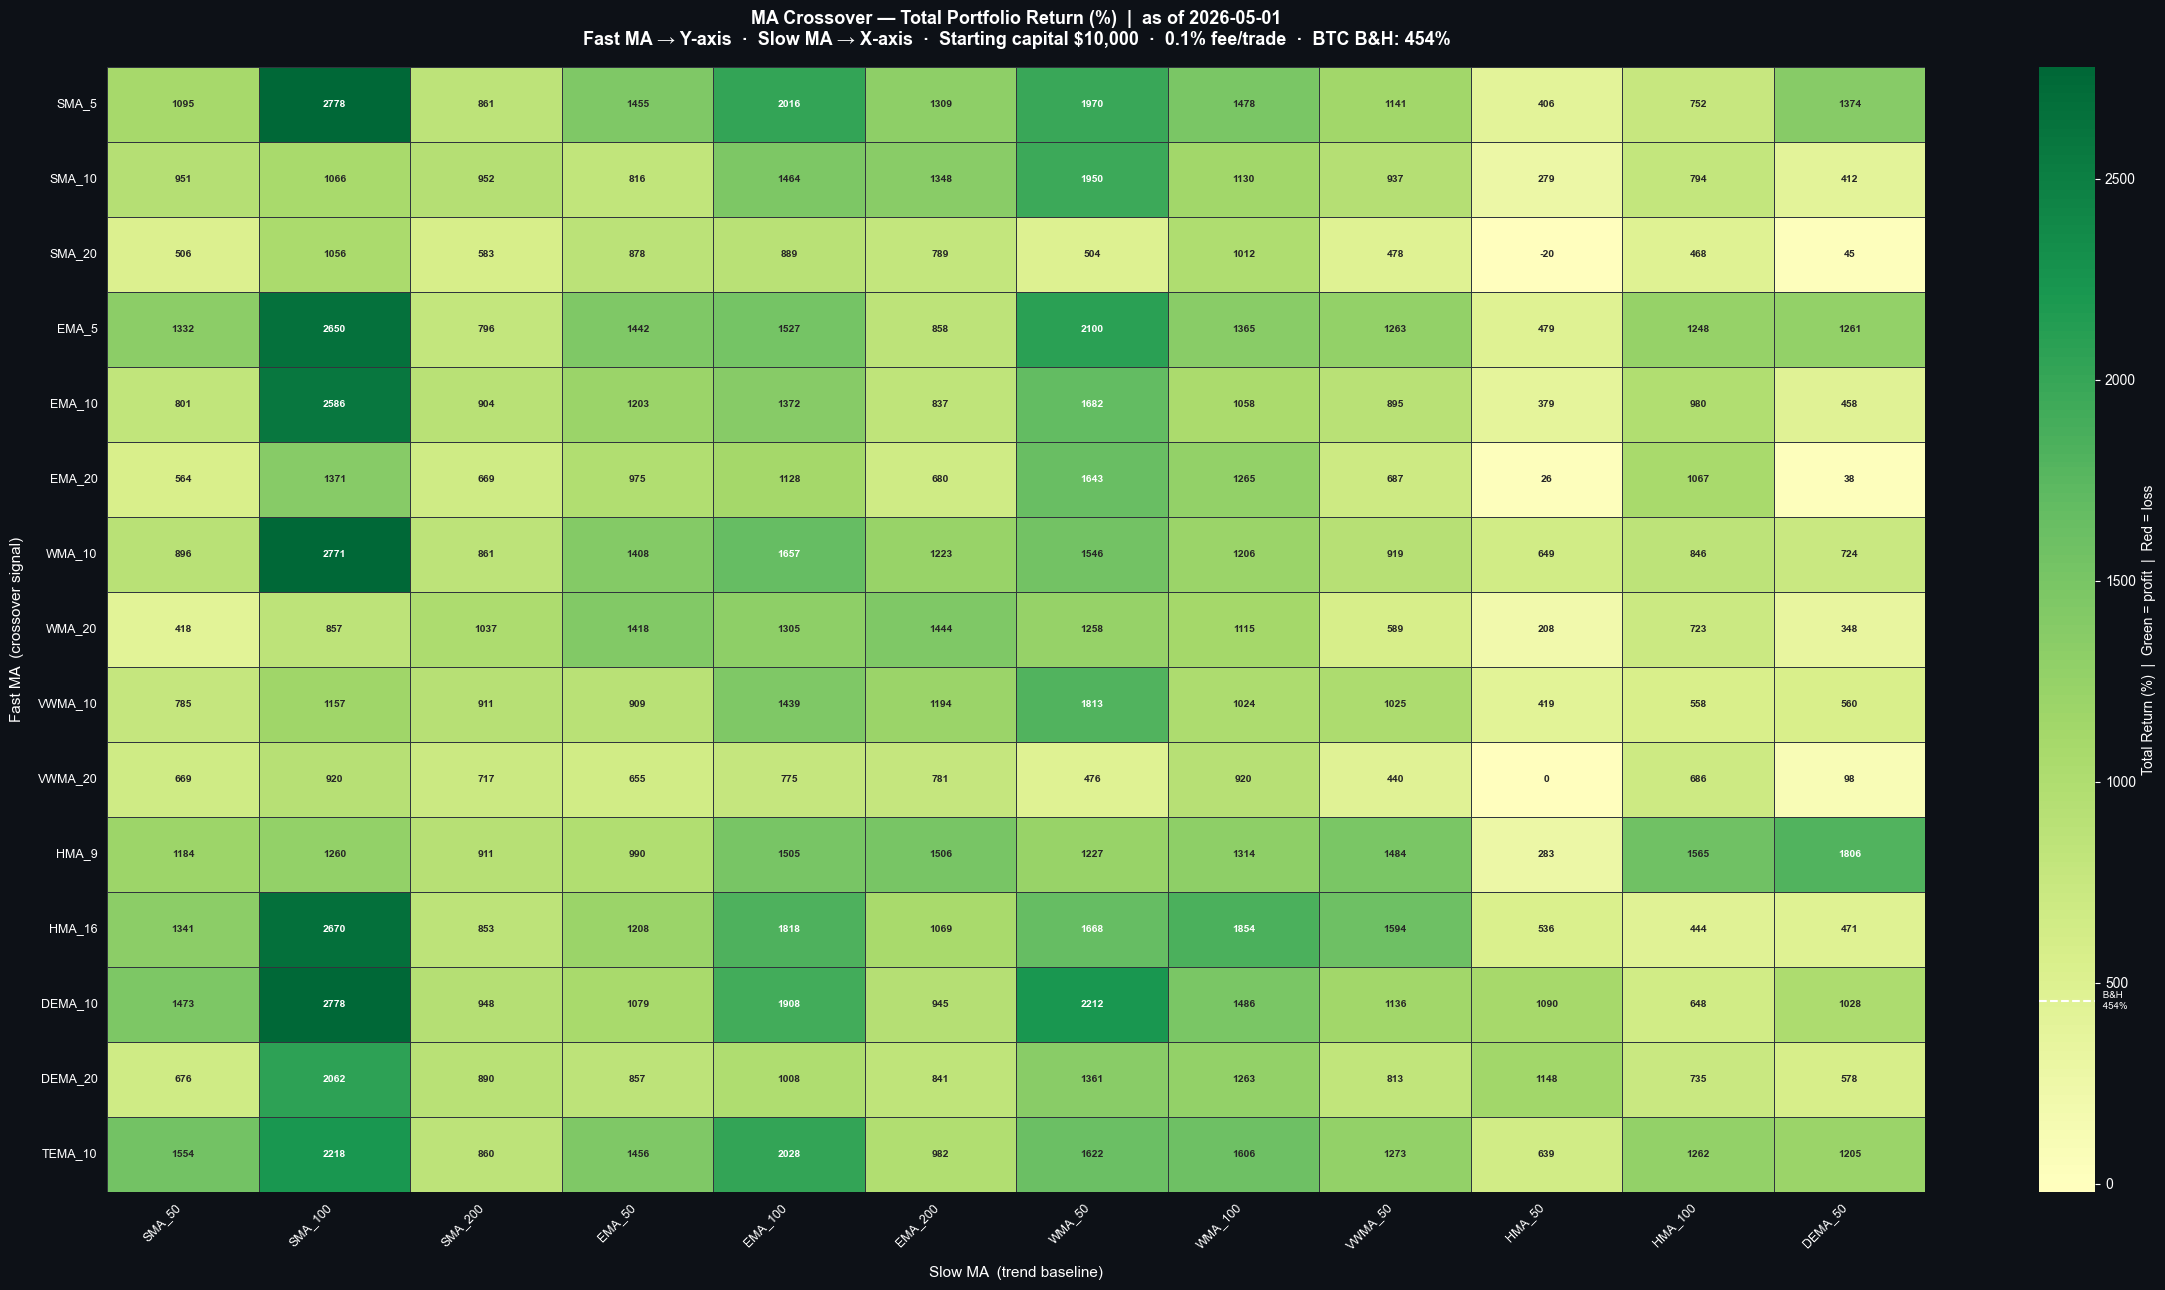

In [9]:
fig, ax = plt.subplots(figsize=(24, 13), facecolor='#0d1117')
ax.set_facecolor('#161b22')

# Mask cells that have no result (NaN)
mask = return_hm.isna()

hm = sns.heatmap(
    return_hm.astype(float),
    annot=True, fmt='.0f',
    cmap='RdYlGn', center=0,
    mask=mask,
    ax=ax,
    linewidths=0.4, linecolor='#30363d',
    annot_kws={'size': 7.5, 'weight': 'bold'},
    cbar_kws={'label': 'Total Return (%)  |  Green = profit  |  Red = loss'},
)

# Draw BTC B&H reference line on the colorbar
cbar = hm.collections[0].colorbar
cbar.ax.axhline(bh_ret, color='white', lw=1.5, linestyle='--')
cbar.ax.text(1.08, bh_ret, f' B&H\n {bh_ret:.0f}%', va='center',
             transform=cbar.ax.get_yaxis_transform(), color='white', fontsize=7)

ax.set_title(
    f'MA Crossover — Total Portfolio Return (%)  |  as of {today_str}\n'
    f'Fast MA → Y-axis  ·  Slow MA → X-axis  ·  Starting capital $10,000  ·  0.1% fee/trade  ·  BTC B&H: {bh_ret:.0f}%',
    color='white', fontsize=13, fontweight='bold', pad=16
)
ax.set_xlabel('Slow MA  (trend baseline)', color='white', fontsize=11, labelpad=10)
ax.set_ylabel('Fast MA  (crossover signal)', color='white', fontsize=11, labelpad=10)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(rotation=0, color='white')
for spine in ax.spines.values(): spine.set_color('#30363d')
plt.tight_layout()
plt.savefig('images/ma_return_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

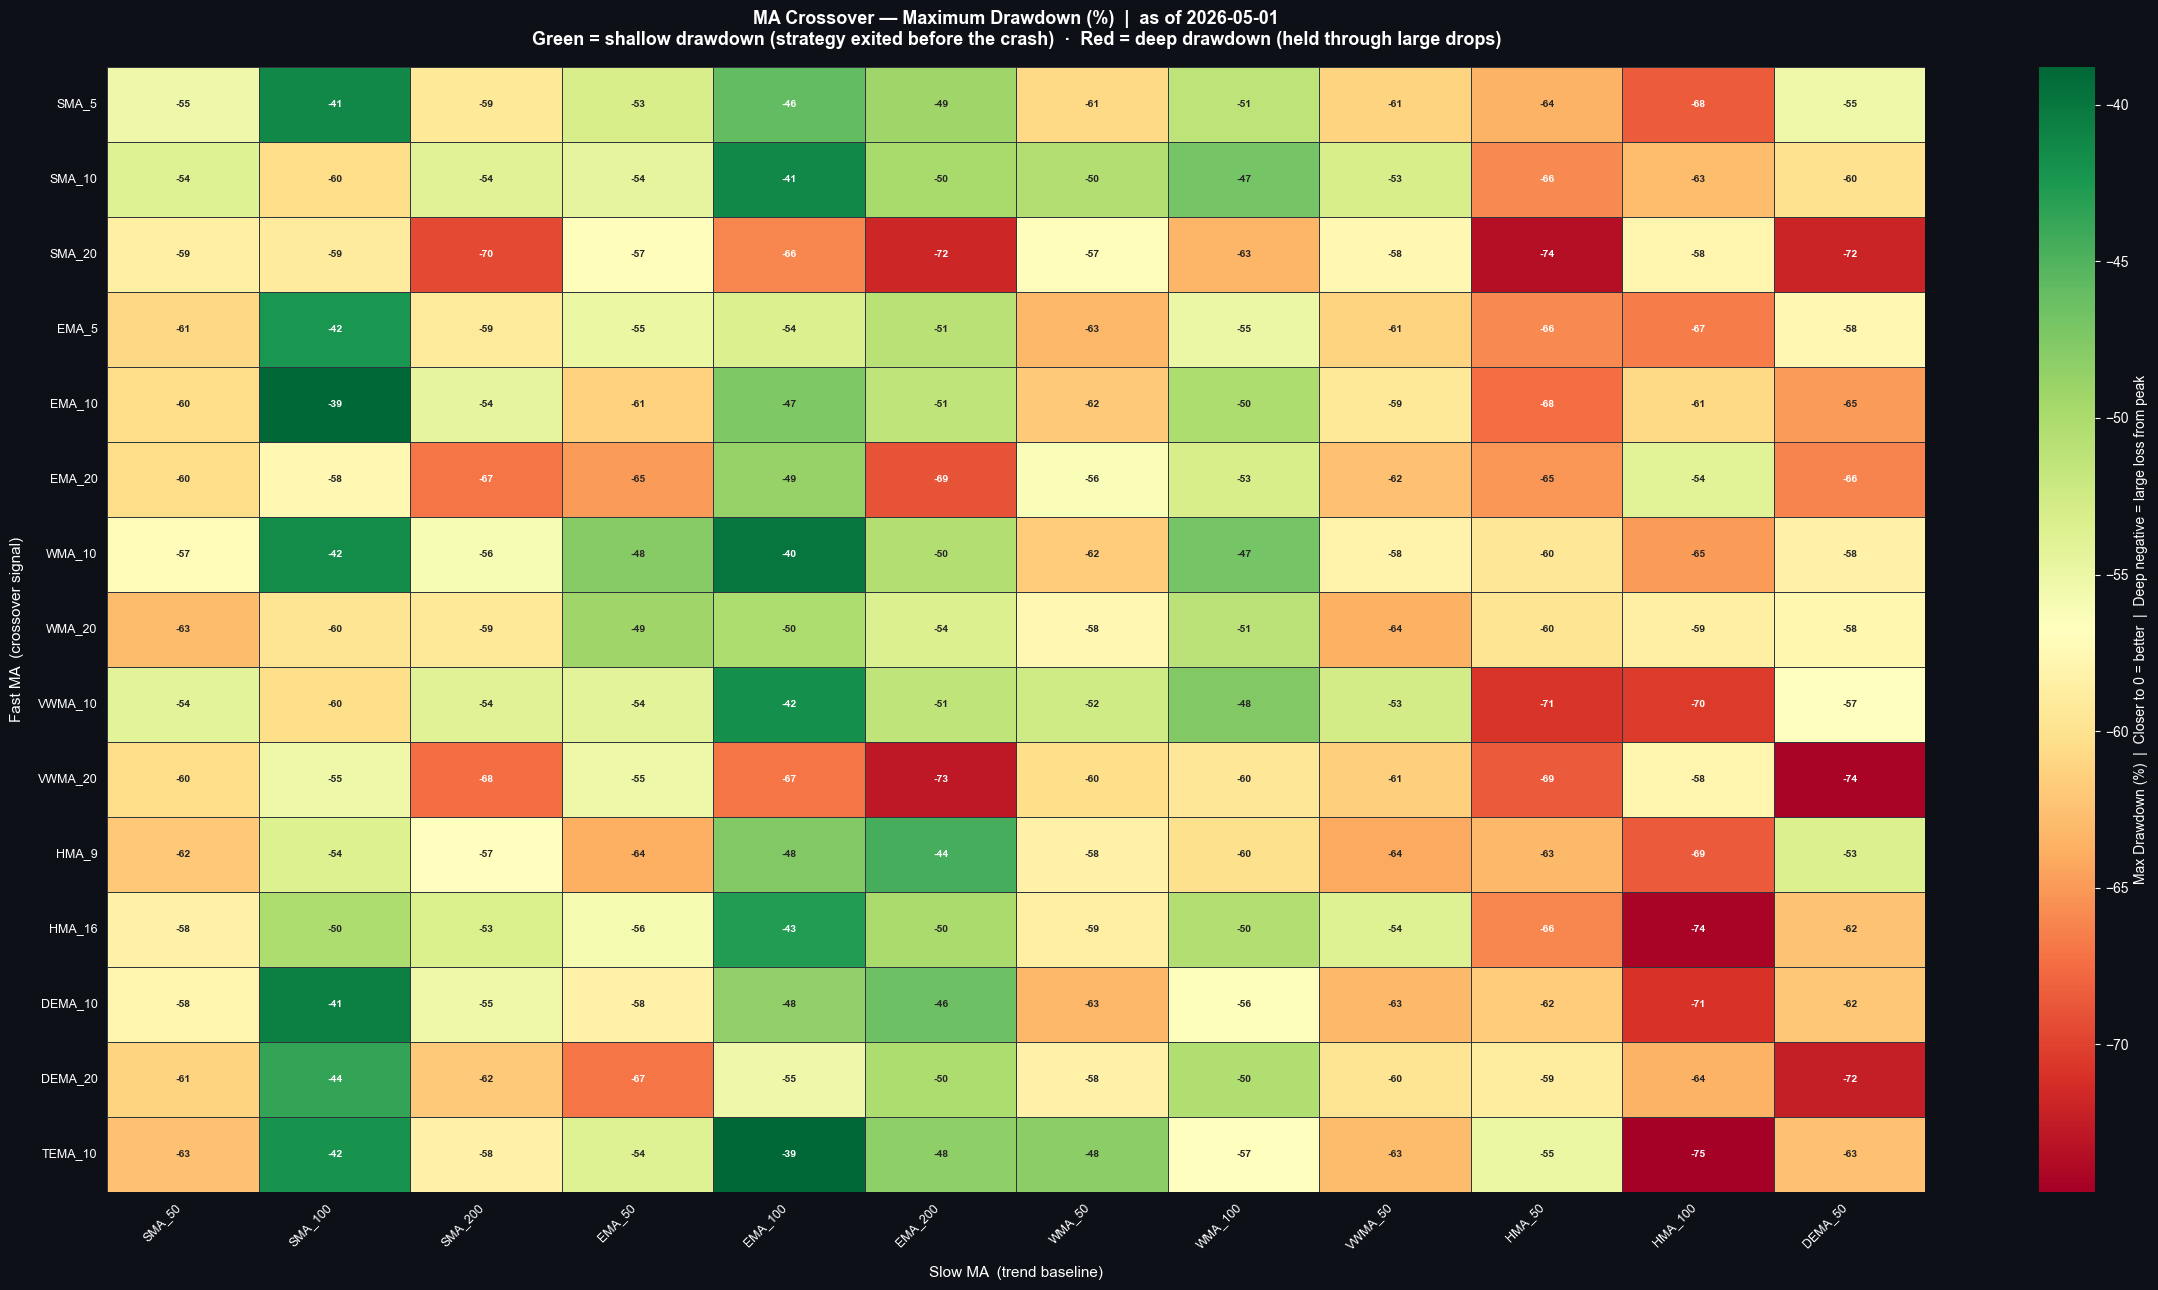

In [10]:
fig, ax = plt.subplots(figsize=(24, 13), facecolor='#0d1117')
ax.set_facecolor('#161b22')

mask = dd_hm.isna()

sns.heatmap(
    dd_hm.astype(float),
    annot=True, fmt='.0f',
    cmap='RdYlGn',      # green = shallow drawdown (closer to 0)
    mask=mask,
    ax=ax,
    linewidths=0.4, linecolor='#30363d',
    annot_kws={'size': 7.5, 'weight': 'bold'},
    cbar_kws={'label': 'Max Drawdown (%)  |  Closer to 0 = better  |  Deep negative = large loss from peak'},
)

ax.set_title(
    f'MA Crossover — Maximum Drawdown (%)  |  as of {today_str}\n'
    f'Green = shallow drawdown (strategy exited before the crash)  ·  Red = deep drawdown (held through large drops)',
    color='white', fontsize=13, fontweight='bold', pad=16
)
ax.set_xlabel('Slow MA  (trend baseline)', color='white', fontsize=11, labelpad=10)
ax.set_ylabel('Fast MA  (crossover signal)', color='white', fontsize=11, labelpad=10)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(rotation=0, color='white')
for spine in ax.spines.values(): spine.set_color('#30363d')
plt.tight_layout()
plt.savefig('images/ma_drawdown_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

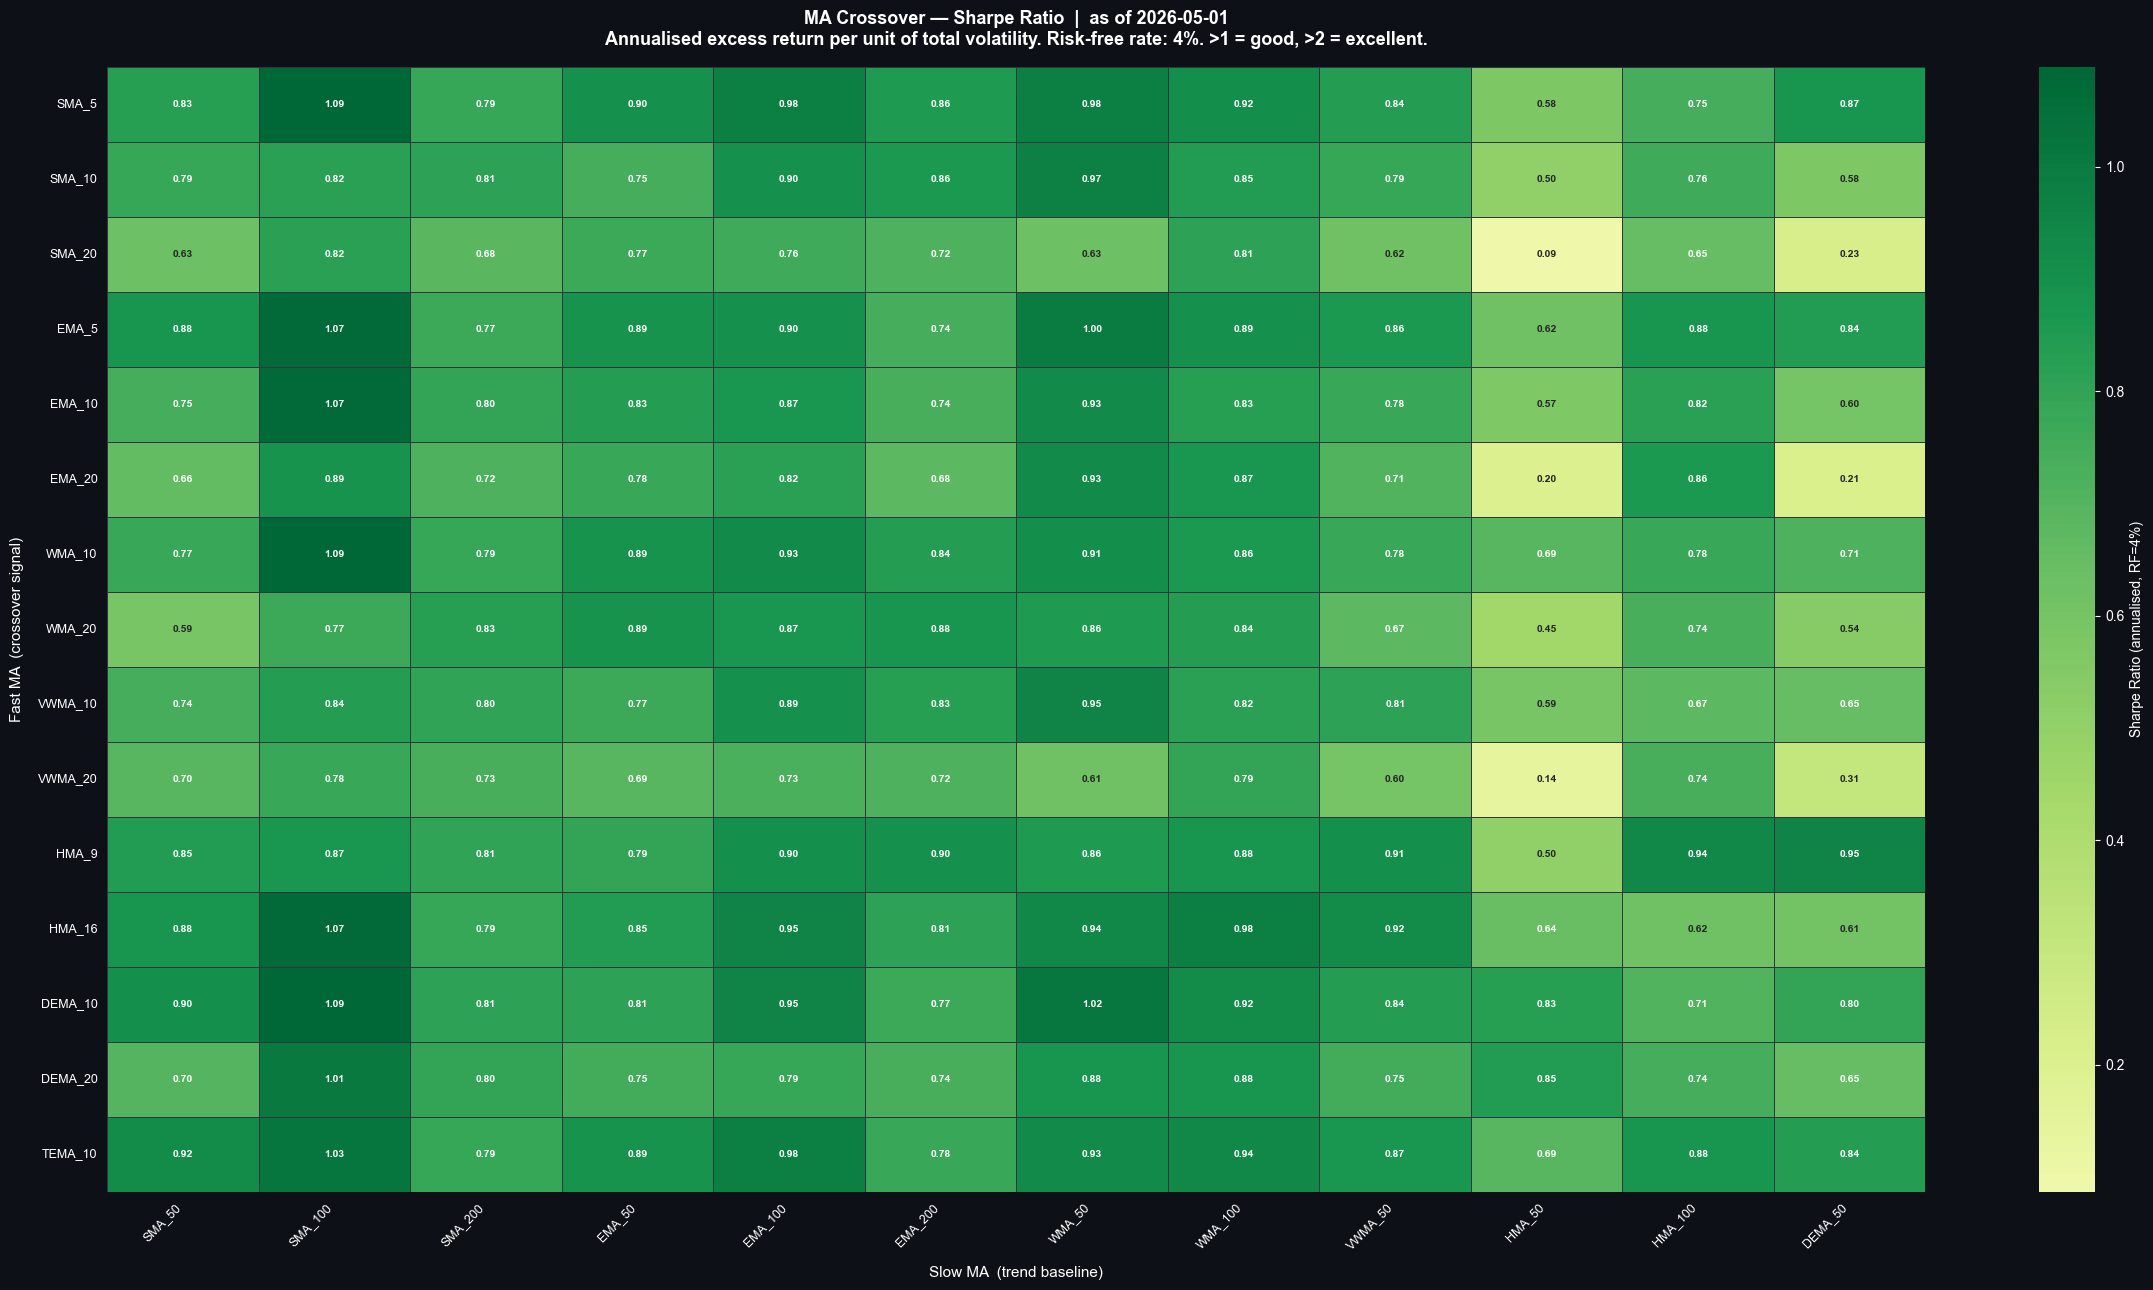

In [11]:
fig, ax = plt.subplots(figsize=(24, 13), facecolor='#0d1117')
ax.set_facecolor('#161b22')

mask = sharpe_hm.isna()

sns.heatmap(
    sharpe_hm.astype(float),
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    mask=mask,
    ax=ax,
    linewidths=0.4, linecolor='#30363d',
    annot_kws={'size': 7.5, 'weight': 'bold'},
    cbar_kws={'label': 'Sharpe Ratio (annualised, RF=4%)'},
)

ax.set_title(
    f'MA Crossover — Sharpe Ratio  |  as of {today_str}\n'
    f'Annualised excess return per unit of total volatility. Risk-free rate: 4%. >1 = good, >2 = excellent.',
    color='white', fontsize=13, fontweight='bold', pad=16
)
ax.set_xlabel('Slow MA  (trend baseline)', color='white', fontsize=11, labelpad=10)
ax.set_ylabel('Fast MA  (crossover signal)', color='white', fontsize=11, labelpad=10)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(rotation=0, color='white')
for spine in ax.spines.values(): spine.set_color('#30363d')
plt.tight_layout()
plt.savefig('images/ma_sharpe_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

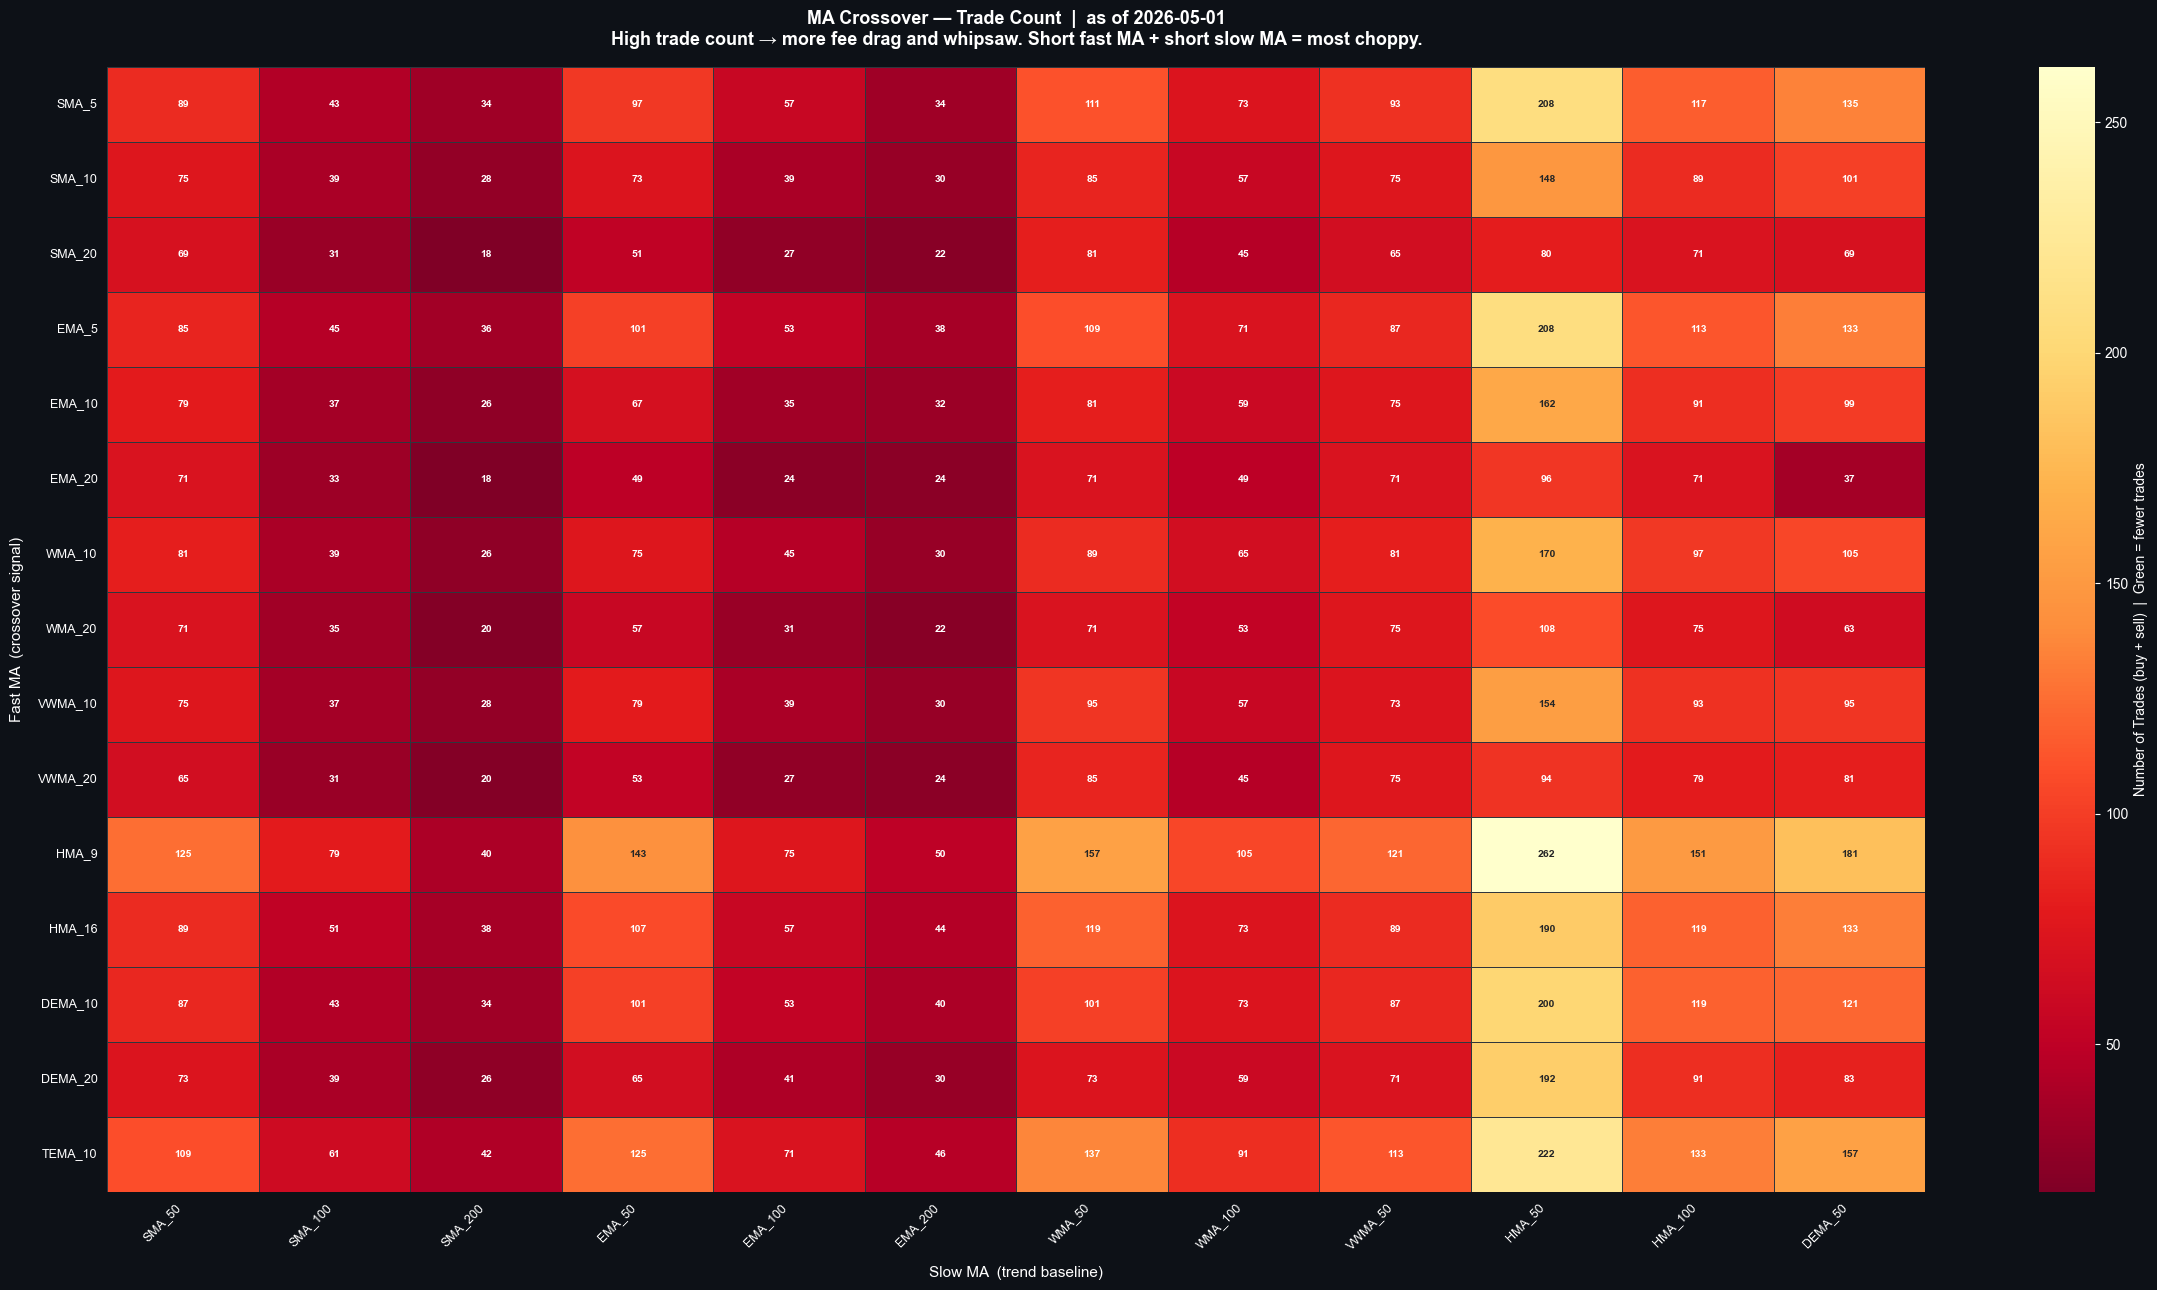

In [12]:
fig, ax = plt.subplots(figsize=(24, 13), facecolor='#0d1117')
ax.set_facecolor('#161b22')

mask = trades_hm.isna()

sns.heatmap(
    trades_hm.astype(float),
    annot=True, fmt='.0f',
    cmap='YlOrRd_r',    # green = fewer trades (less fee drag, less whipsaw)
    mask=mask,
    ax=ax,
    linewidths=0.4, linecolor='#30363d',
    annot_kws={'size': 7.5, 'weight': 'bold'},
    cbar_kws={'label': 'Number of Trades (buy + sell)  |  Green = fewer trades'},
)

ax.set_title(
    f'MA Crossover — Trade Count  |  as of {today_str}\n'
    f'High trade count → more fee drag and whipsaw. Short fast MA + short slow MA = most choppy.',
    color='white', fontsize=13, fontweight='bold', pad=16
)
ax.set_xlabel('Slow MA  (trend baseline)', color='white', fontsize=11, labelpad=10)
ax.set_ylabel('Fast MA  (crossover signal)', color='white', fontsize=11, labelpad=10)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(rotation=0, color='white')
for spine in ax.spines.values(): spine.set_color('#30363d')
plt.tight_layout()
plt.savefig('images/ma_trades_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

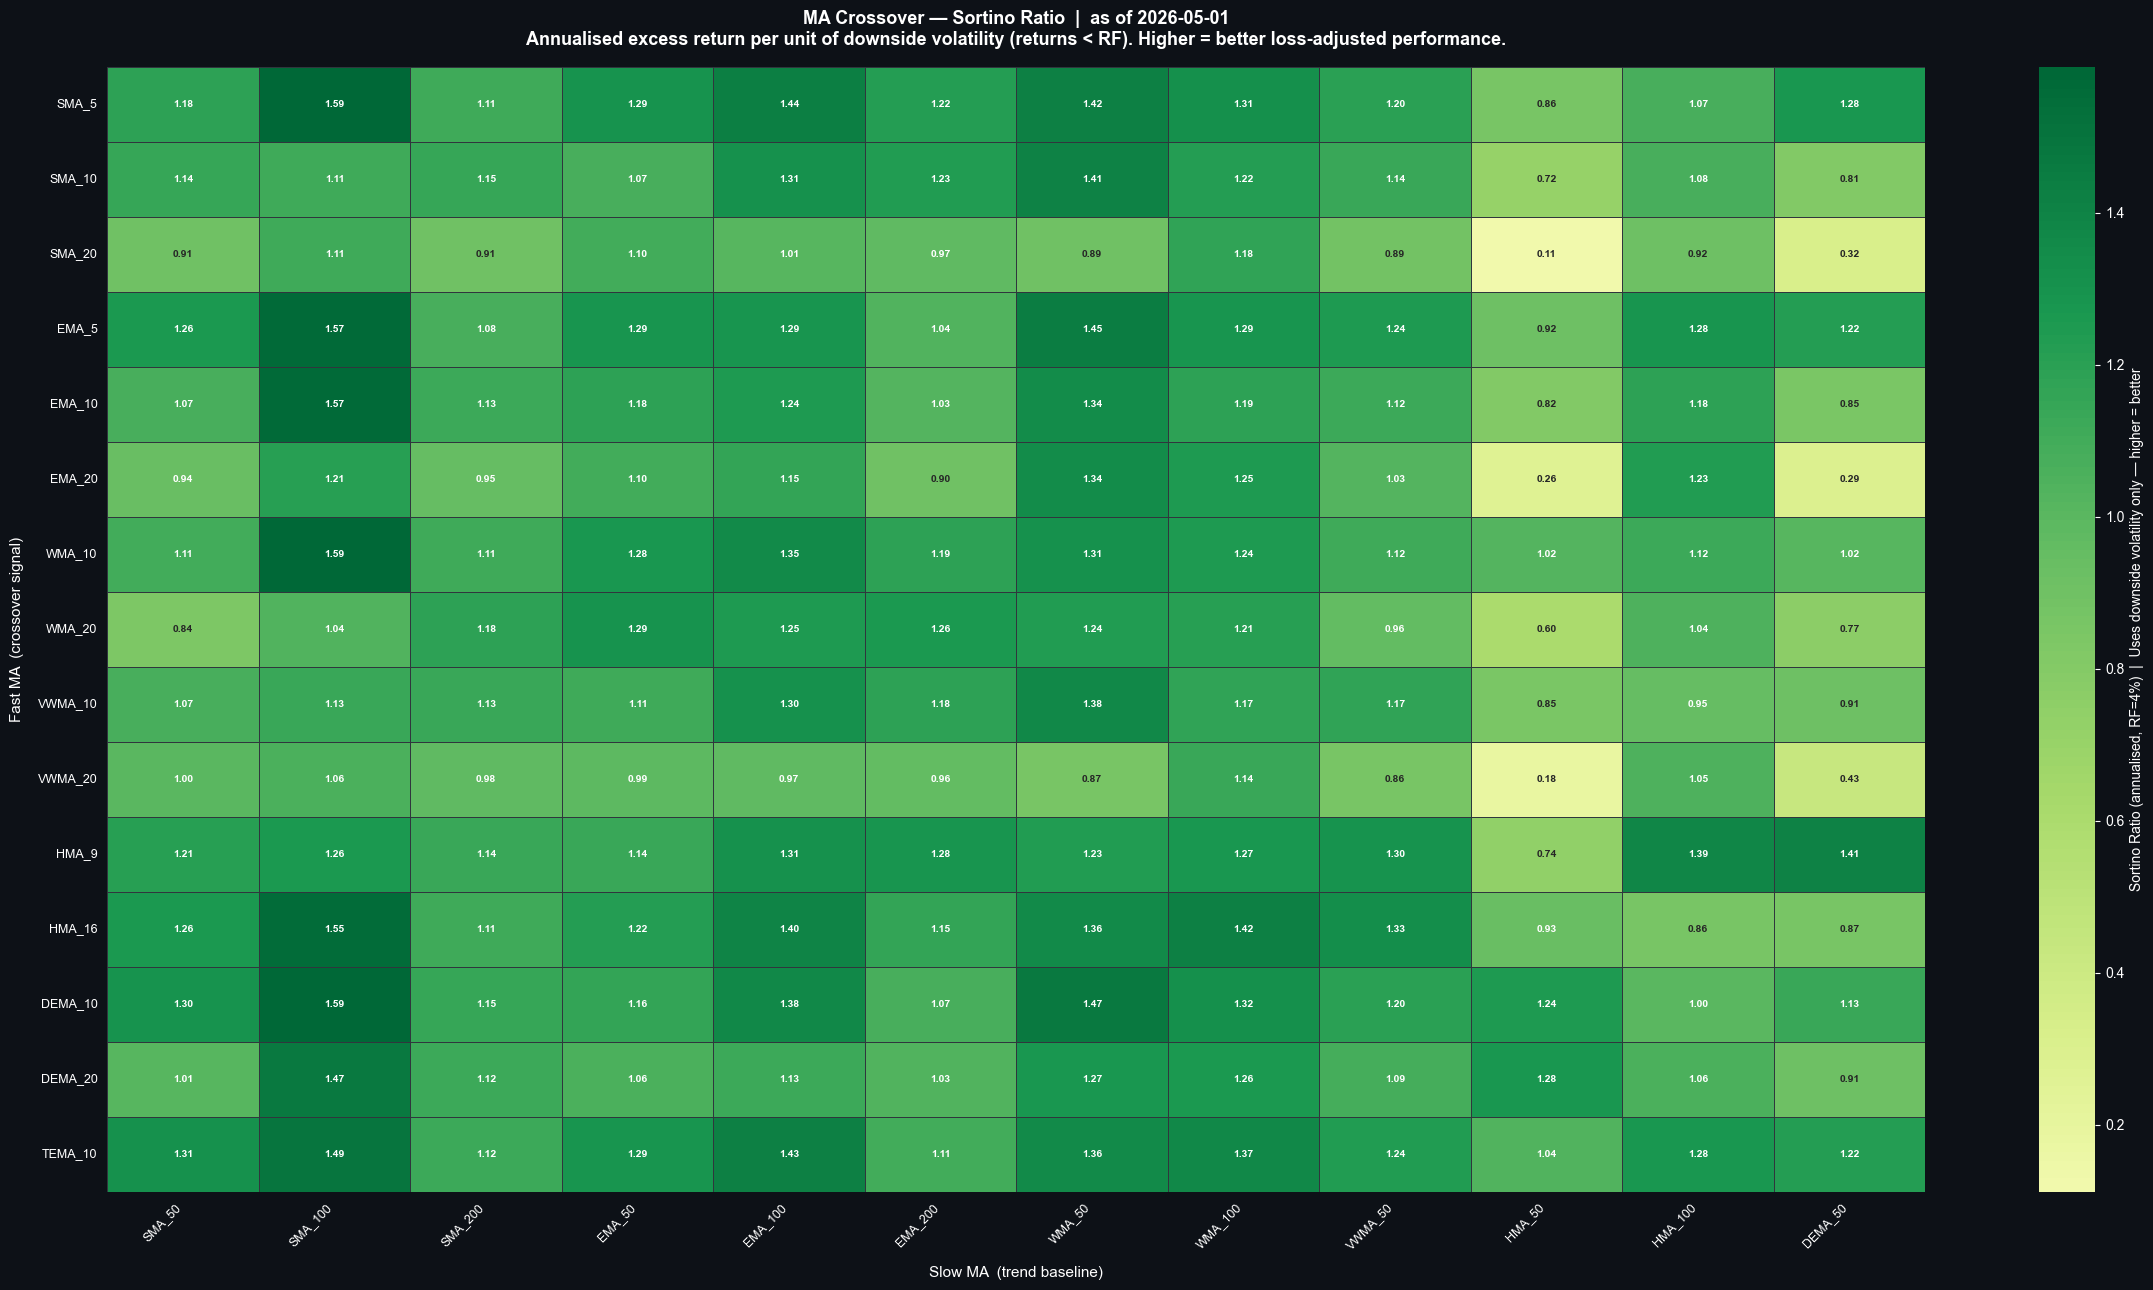

Sortino range: 0.11 → 1.59


In [13]:
# ── Sortino ratio heatmap ─────────────────────────────────────────────────────
# Sortino uses only downside volatility (returns < RF) as the risk denominator.
# It rewards strategies that have big gains but few large losses.

sortino_hm = pd.DataFrame(np.nan, index=fast_labels, columns=slow_labels)
for (fk, sk), r in results.items():
    sortino_hm.loc[fk, sk] = r['sortino']

fig, ax = plt.subplots(figsize=(24, 13), facecolor='#0d1117')
ax.set_facecolor('#161b22')

mask = sortino_hm.isna()

sns.heatmap(
    sortino_hm.astype(float),
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    mask=mask,
    ax=ax,
    linewidths=0.4, linecolor='#30363d',
    annot_kws={'size': 7.5, 'weight': 'bold'},
    cbar_kws={'label': 'Sortino Ratio (annualised, RF=4%)  |  Uses downside volatility only — higher = better'},
)

ax.set_title(
    f'MA Crossover — Sortino Ratio  |  as of {today_str}\n'
    f'Annualised excess return per unit of downside volatility (returns < RF). Higher = better loss-adjusted performance.',
    color='white', fontsize=13, fontweight='bold', pad=16
)
ax.set_xlabel('Slow MA  (trend baseline)', color='white', fontsize=11, labelpad=10)
ax.set_ylabel('Fast MA  (crossover signal)', color='white', fontsize=11, labelpad=10)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(rotation=0, color='white')
for spine in ax.spines.values(): spine.set_color('#30363d')
plt.tight_layout()
plt.savefig('images/ma_sortino_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'Sortino range: {sortino_hm.values.min():.2f} → {sortino_hm.values.max():.2f}')

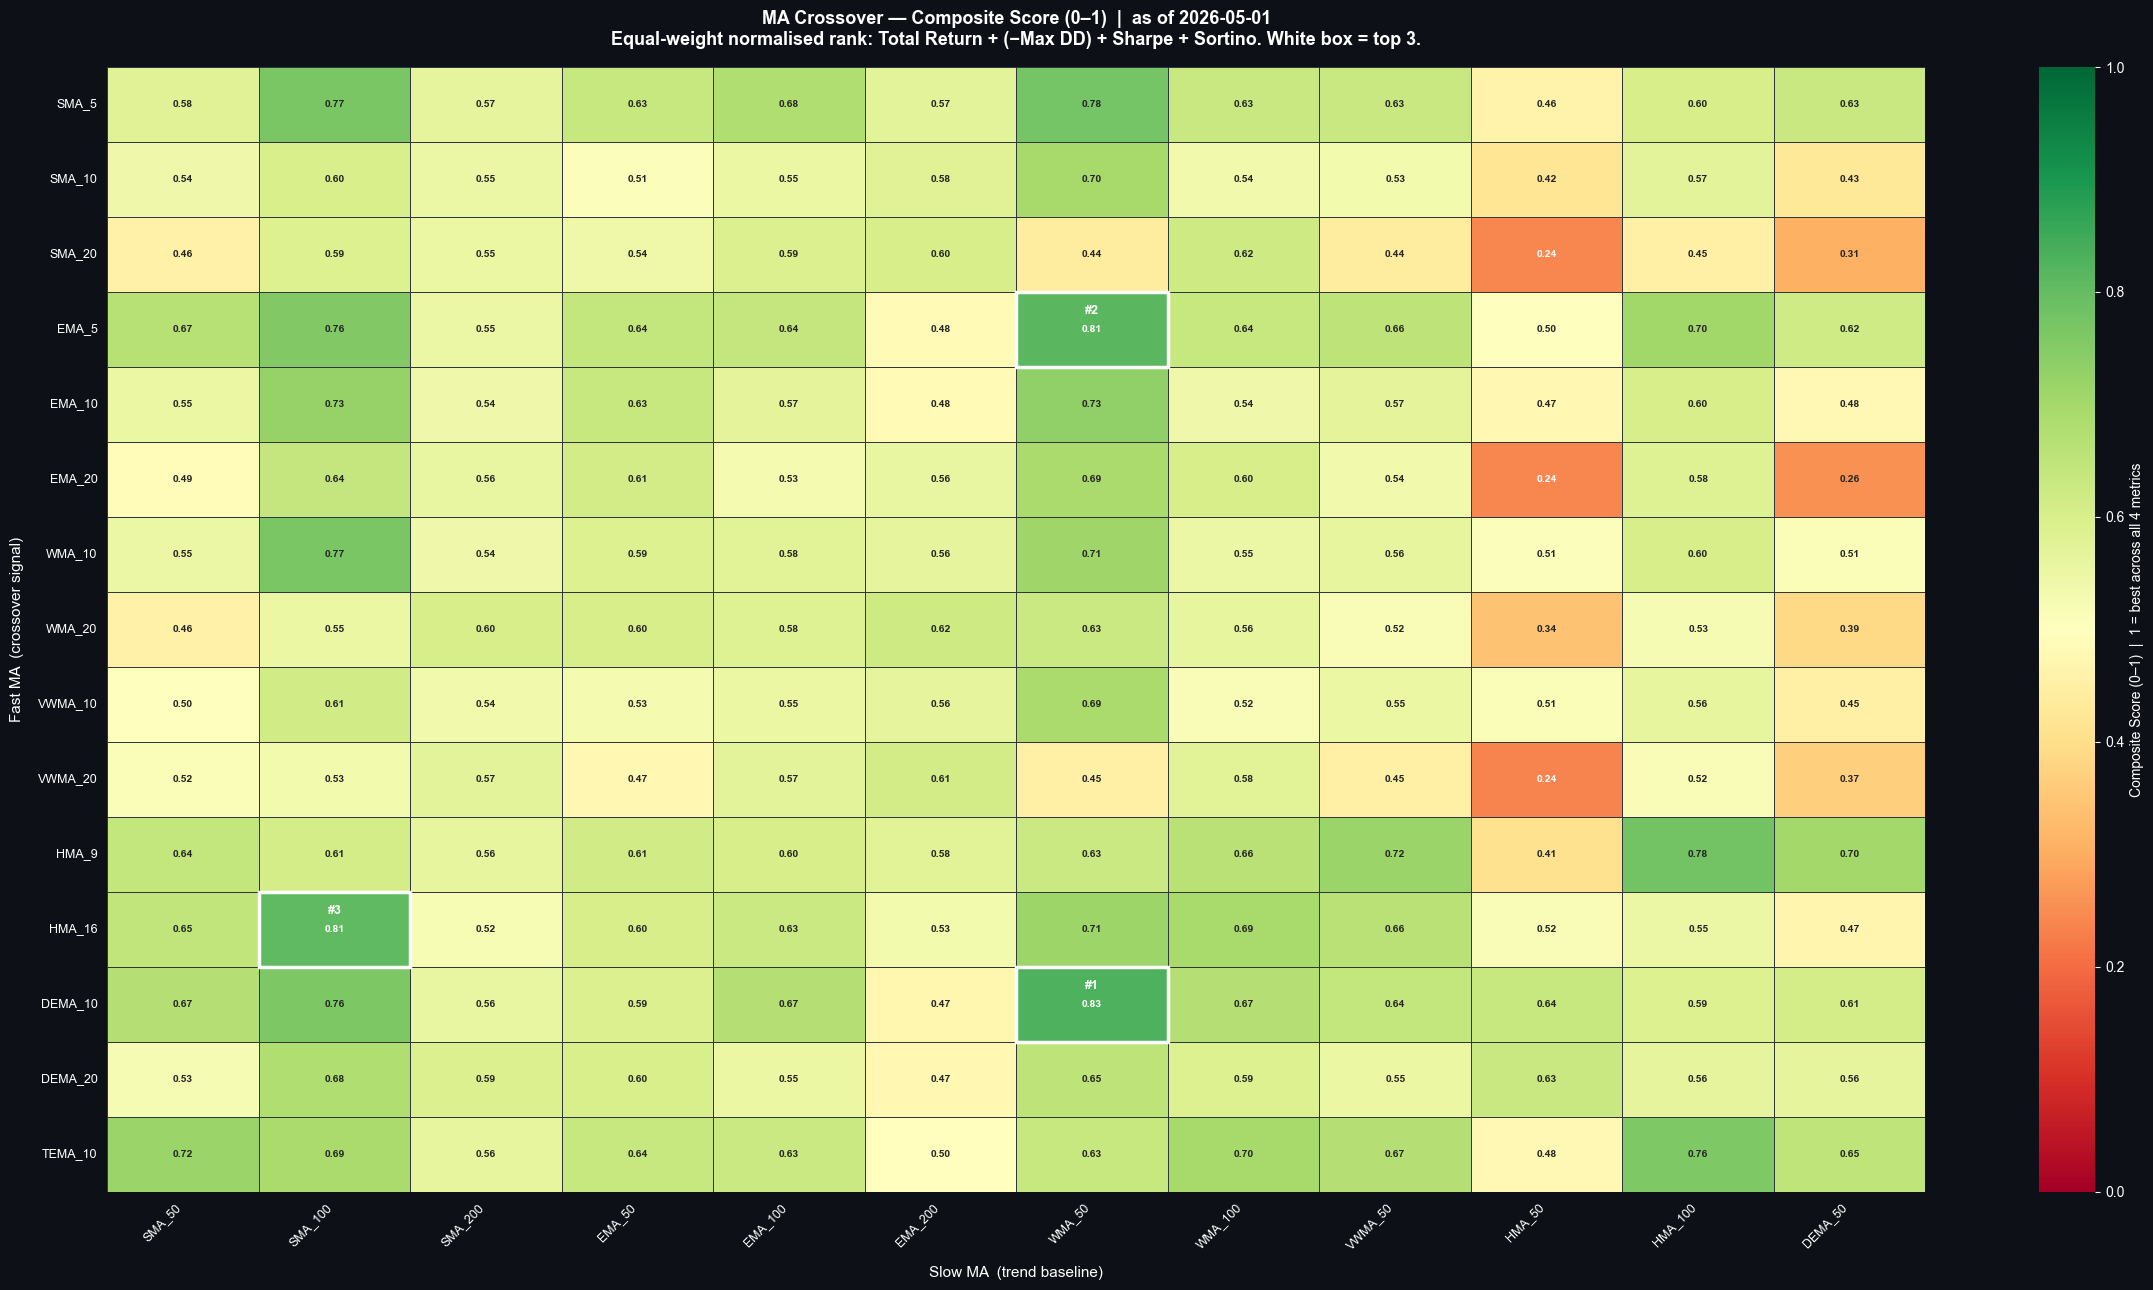

TOP 5 BY COMPOSITE SCORE
  #1  DEMA_10 × WMA_50  —  score=0.831  |  return=+2212%  dd=-63%  sharpe=1.02  sortino=1.47
  #2  EMA_5 × WMA_50  —  score=0.814  |  return=+2100%  dd=-63%  sharpe=1.00  sortino=1.45
  #3  HMA_16 × SMA_100  —  score=0.808  |  return=+2670%  dd=-50%  sharpe=1.07  sortino=1.55
  #4  HMA_9 × HMA_100  —  score=0.778  |  return=+1565%  dd=-69%  sharpe=0.94  sortino=1.39
  #5  SMA_5 × WMA_50  —  score=0.775  |  return=+1970%  dd=-61%  sharpe=0.98  sortino=1.42


In [14]:
# ── Composite score heatmap ──────────────────────────────────────────────────
# Normalise each metric to [0, 1] then average. Captures return, risk, and
# risk-adjusted return simultaneously so the best all-round combo floats up.

def norm01(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn) if mx > mn else np.zeros_like(arr)

keys     = list(results.keys())
ret_arr  = np.array([results[k]['total_return'] for k in keys])
dd_arr   = np.array([-results[k]['max_drawdown']  for k in keys])   # negate: shallower = higher
sh_arr   = np.array([results[k]['sharpe']          for k in keys])
so_arr   = np.array([results[k]['sortino']         for k in keys])

composite = (norm01(ret_arr) + norm01(dd_arr) + norm01(sh_arr) + norm01(so_arr)) / 4

composite_hm = pd.DataFrame(np.nan, index=fast_labels, columns=slow_labels)
for i, (fk, sk) in enumerate(keys):
    composite_hm.loc[fk, sk] = round(float(composite[i]), 3)

fig, ax = plt.subplots(figsize=(24, 13), facecolor='#0d1117')
ax.set_facecolor('#161b22')

mask = composite_hm.isna()
sns.heatmap(
    composite_hm.astype(float),
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    mask=mask,
    ax=ax,
    linewidths=0.4, linecolor='#30363d',
    annot_kws={'size': 7.5, 'weight': 'bold'},
    cbar_kws={'label': 'Composite Score (0–1)  |  1 = best across all 4 metrics'},
)

# Highlight top-3 cells with a white border
top3_idx = np.argsort(composite)[-3:][::-1]
for rank, idx in enumerate(top3_idx, 1):
    fk, sk = keys[idx]
    row = fast_labels.index(fk)
    col = slow_labels.index(sk)
    ax.add_patch(plt.Rectangle((col, row), 1, 1, fill=False, edgecolor='white', lw=2.5))
    ax.text(col + 0.5, row + 0.18, f'#{rank}', ha='center', va='top',
            color='white', fontsize=9, fontweight='bold')

ax.set_title(
    f'MA Crossover — Composite Score (0–1)  |  as of {today_str}\n'
    f'Equal-weight normalised rank: Total Return + (−Max DD) + Sharpe + Sortino. White box = top 3.',
    color='white', fontsize=13, fontweight='bold', pad=16
)
ax.set_xlabel('Slow MA  (trend baseline)', color='white', fontsize=11, labelpad=10)
ax.set_ylabel('Fast MA  (crossover signal)', color='white', fontsize=11, labelpad=10)
ax.tick_params(colors='white', labelsize=9)
plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(rotation=0, color='white')
for spine in ax.spines.values(): spine.set_color('#30363d')
plt.tight_layout()
plt.savefig('images/ma_composite_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('TOP 5 BY COMPOSITE SCORE')
top5_comp = sorted(zip(keys, composite), key=lambda x: x[1], reverse=True)[:5]
for rank, ((fk, sk), score) in enumerate(top5_comp, 1):
    r = results[(fk, sk)]
    print(f'  #{rank}  {fk} × {sk}  —  score={score:.3f}  |  '
          f'return={r["total_return"]:+.0f}%  dd={r["max_drawdown"]:.0f}%  '
          f'sharpe={r["sharpe"]:.2f}  sortino={r["sortino"]:.2f}')

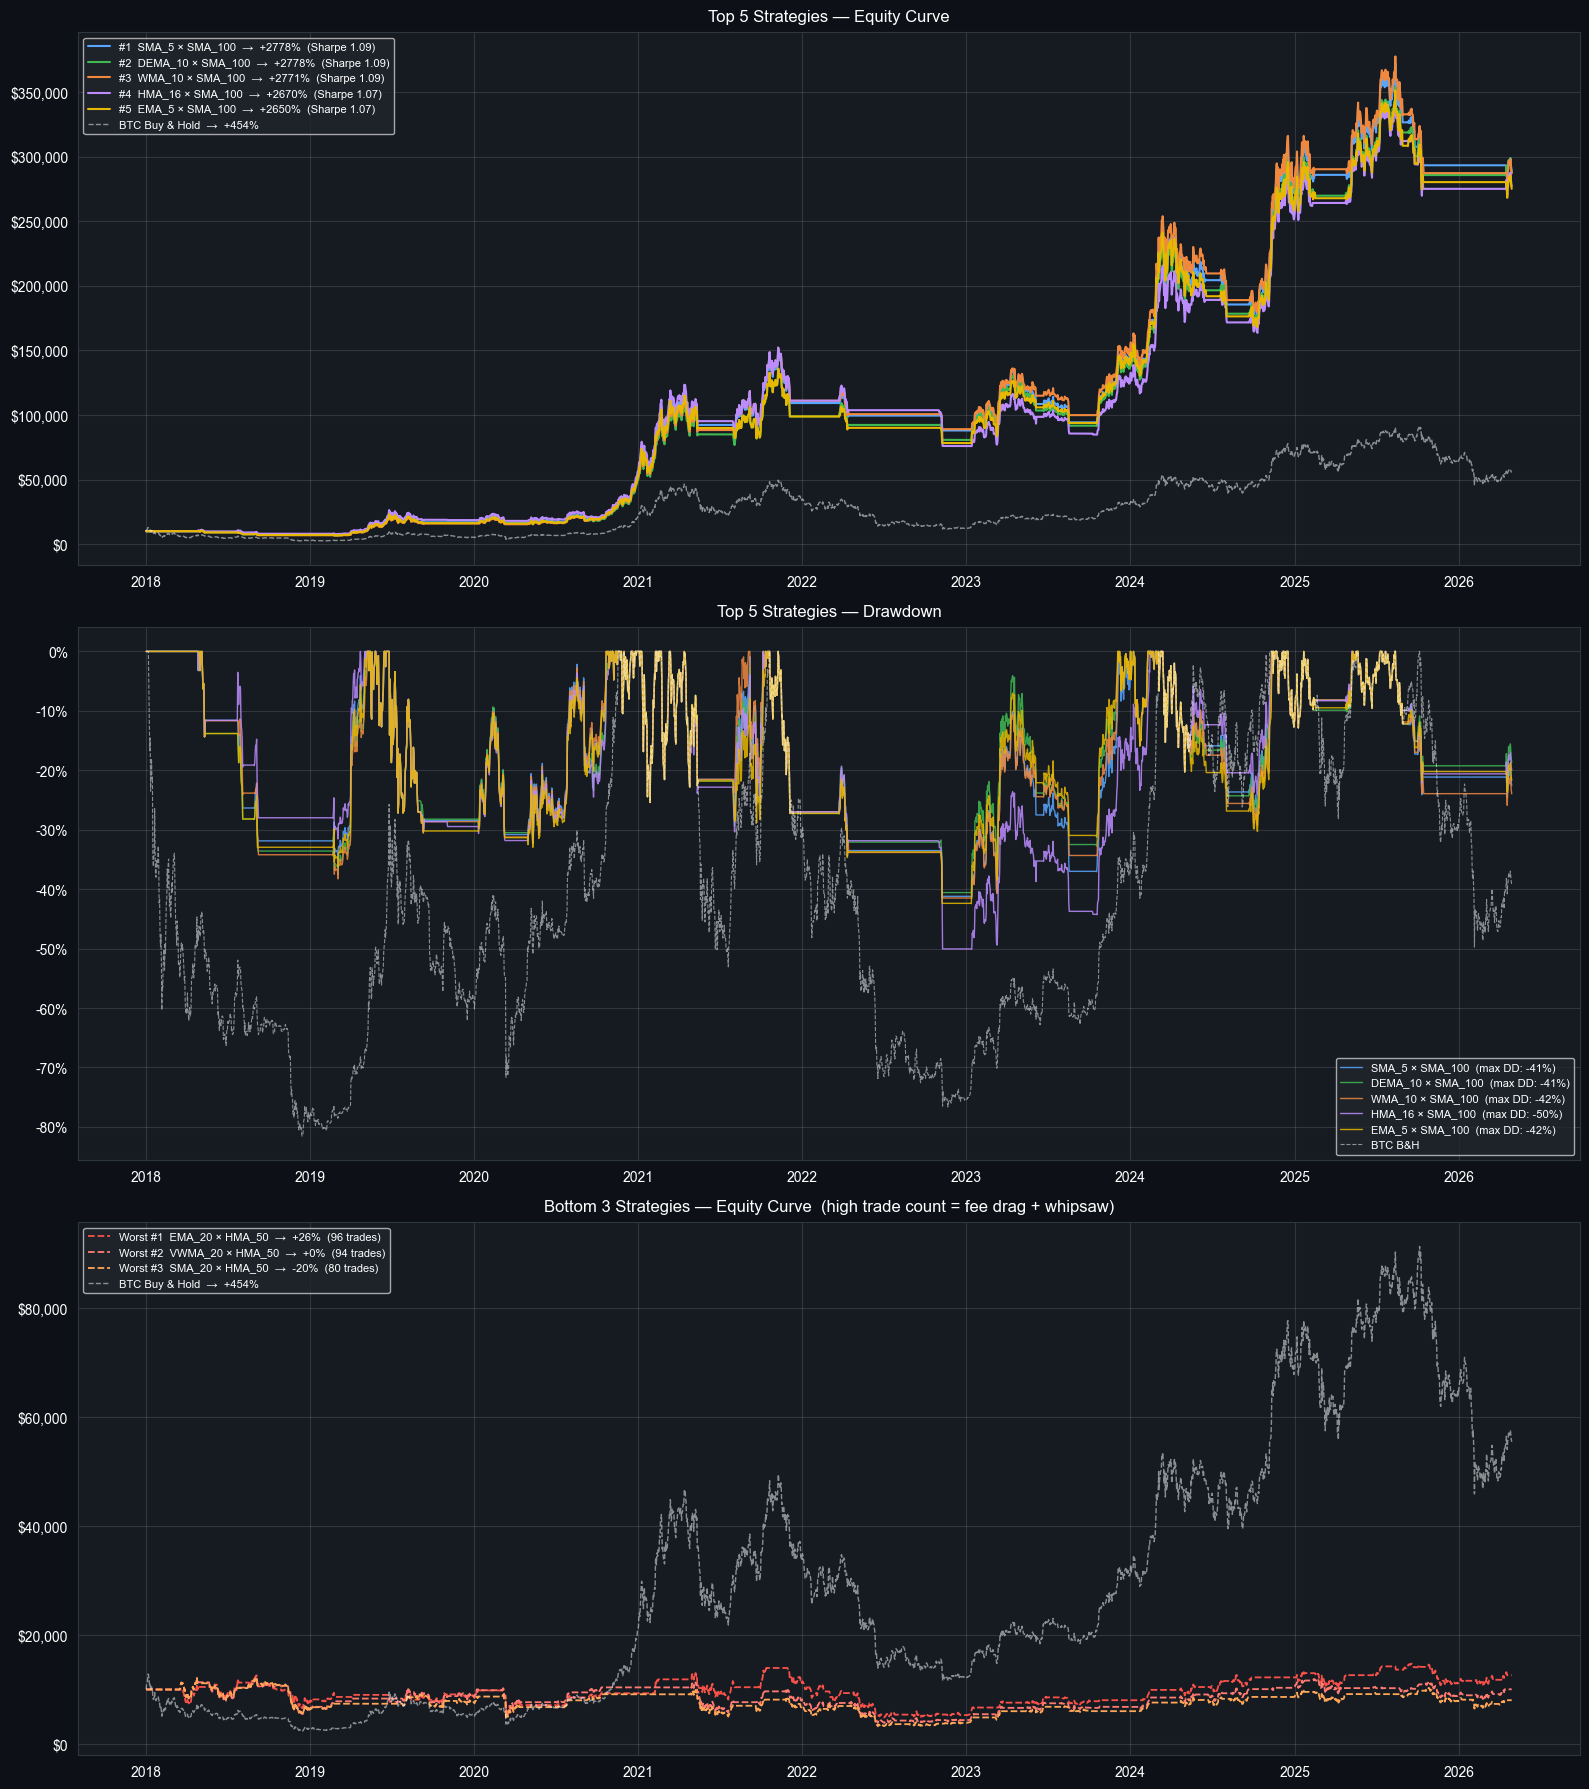

In [15]:
# ── Top 5 and bottom 3 strategies vs BTC Buy & Hold ───────────────────────
sorted_res = sorted(results.items(), key=lambda x: x[1]['total_return'], reverse=True)
top5    = sorted_res[:5]
bottom3 = sorted_res[-3:]

# Helper: align a strategy pv to the full price index
def align_pv(pv, full_index, capital=10_000):
    return pv.reindex(full_index).fillna(capital)

fig, axes = plt.subplots(3, 1, figsize=(16, 18), facecolor='#0d1117')
top_colors    = ['#58a6ff', '#3fb950', '#f0883e', '#bc8cff', '#e6b800']
bottom_colors = ['#f85149', '#ff7b72', '#ffa657']

# ── Panel 1: Top 5 equity curves ───────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#161b22')
for i, ((fk, sk), r) in enumerate(top5):
    pv = align_pv(r['pv'], price_s.index)
    ax.plot(pv.index, pv.values, color=top_colors[i], lw=1.5,
            label=f'#{i+1}  {fk} × {sk}  →  {r["total_return"]:+.0f}%  (Sharpe {r["sharpe"]:.2f})')
ax.plot(bh_pv.index, bh_pv.values, color='white', lw=1.0, ls='--', alpha=0.5,
        label=f'BTC Buy & Hold  →  {bh_ret:+.0f}%')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Top 5 Strategies — Equity Curve', color='white', pad=8)
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=8)
ax.grid(alpha=0.12)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#30363d')

# ── Panel 2: Top 5 drawdown ────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor('#161b22')
for i, ((fk, sk), r) in enumerate(top5):
    pv = align_pv(r['pv'], price_s.index)
    dd = (pv - pv.cummax()) / pv.cummax() * 100
    ax.plot(pv.index, dd.values, color=top_colors[i], lw=1.0, alpha=0.85,
            label=f'{fk} × {sk}  (max DD: {r["max_drawdown"]:.0f}%)')
bh_dd = (bh_pv - bh_pv.cummax()) / bh_pv.cummax() * 100
ax.plot(bh_pv.index, bh_dd.values, color='white', lw=0.8, ls='--', alpha=0.5, label='BTC B&H')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_title('Top 5 Strategies — Drawdown', color='white', pad=8)
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=8)
ax.grid(alpha=0.12)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#30363d')

# ── Panel 3: Bottom 3 vs B&H ───────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor('#161b22')
for i, ((fk, sk), r) in enumerate(bottom3):
    pv = align_pv(r['pv'], price_s.index)
    ax.plot(pv.index, pv.values, color=bottom_colors[i], lw=1.3, ls='--',
            label=f'Worst #{i+1}  {fk} × {sk}  →  {r["total_return"]:+.0f}%  ({r["n_trades"]} trades)')
ax.plot(bh_pv.index, bh_pv.values, color='white', lw=1.0, ls='--', alpha=0.5,
        label=f'BTC Buy & Hold  →  {bh_ret:+.0f}%')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Bottom 3 Strategies — Equity Curve  (high trade count = fee drag + whipsaw)',
             color='white', pad=8)
ax.legend(facecolor='#21262d', labelcolor='white', fontsize=8)
ax.grid(alpha=0.12)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#30363d')

plt.tight_layout()
plt.savefig('images/ma_equity_curves.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

          MA CROSSOVER GRID — FINAL SUMMARY
  Period:              2018-01-01 → 2026-04-29
  Total combinations:  180
  BTC Buy & Hold:      454.3%
  Beat B&H:            163 / 180 strategies

  ★ Highest Return:    SMA_5 × SMA_100
    Return: +2778.3%  |  Max DD: -41.3%  |  Sharpe: 1.089  |  Trades: 43

  ★ Best Risk-Adjusted: SMA_5 × SMA_100
    Return: +2778.3%  |  Max DD: -41.3%  |  Sharpe: 1.089  |  Trades: 43

  ✗ Worst Return:      SMA_20 × HMA_50
    Return: -19.7%  |  Max DD: -73.5%  |  Sharpe: 0.087  |  Trades: 80


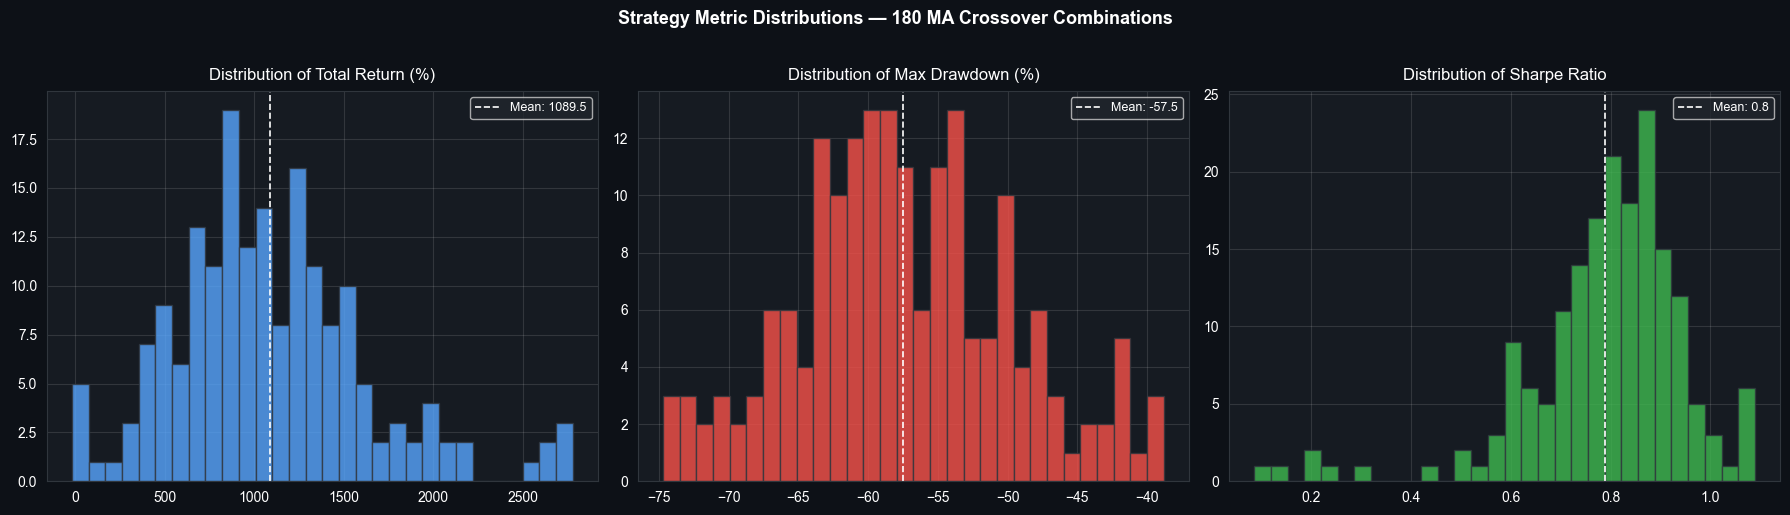

In [16]:
# ── Final summary ───────────────────────────────────────────────────────────
best_key  = sorted_res[0][0]
best_res  = sorted_res[0][1]
worst_key = sorted_res[-1][0]
worst_res = sorted_res[-1][1]

# Best risk-adjusted (highest Sharpe among top-quartile return strategies)
top_q = [item for item in sorted_res if item[1]['total_return'] > np.percentile(all_returns, 75)]
best_sharpe_key = max(top_q, key=lambda x: x[1]['sharpe'])[0]
best_sharpe_res = results[best_sharpe_key]

print('=' * 60)
print('          MA CROSSOVER GRID — FINAL SUMMARY')
print('=' * 60)
print(f'  Period:              {price_s.index[0].date()} → {price_s.index[-1].date()}')
print(f'  Total combinations:  {len(results)}')
print(f'  BTC Buy & Hold:      {bh_ret:.1f}%')
print(f'  Beat B&H:            {sum(r["total_return"]>bh_ret for r in results.values())} / {len(results)} strategies')
print()
print(f'  ★ Highest Return:    {best_key[0]} × {best_key[1]}')
print(f'    Return: {best_res["total_return"]:+.1f}%  |  Max DD: {best_res["max_drawdown"]:.1f}%  |  Sharpe: {best_res["sharpe"]:.3f}  |  Trades: {best_res["n_trades"]}')
print()
print(f'  ★ Best Risk-Adjusted: {best_sharpe_key[0]} × {best_sharpe_key[1]}')
print(f'    Return: {best_sharpe_res["total_return"]:+.1f}%  |  Max DD: {best_sharpe_res["max_drawdown"]:.1f}%  |  Sharpe: {best_sharpe_res["sharpe"]:.3f}  |  Trades: {best_sharpe_res["n_trades"]}')
print()
print(f'  ✗ Worst Return:      {worst_key[0]} × {worst_key[1]}')
print(f'    Return: {worst_res["total_return"]:+.1f}%  |  Max DD: {worst_res["max_drawdown"]:.1f}%  |  Sharpe: {worst_res["sharpe"]:.3f}  |  Trades: {worst_res["n_trades"]}')
print('=' * 60)

# Distribution of returns
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0d1117')
for ax, metric, label, color in [
    (axes[0], [r['total_return'] for r in results.values()], 'Total Return (%)', '#58a6ff'),
    (axes[1], [r['max_drawdown'] for r in results.values()], 'Max Drawdown (%)', '#f85149'),
    (axes[2], [r['sharpe']       for r in results.values()], 'Sharpe Ratio',     '#3fb950'),
]:
    ax.set_facecolor('#161b22')
    ax.hist(metric, bins=30, color=color, alpha=0.8, edgecolor='#30363d')
    ax.axvline(np.mean(metric), color='white', lw=1.2, ls='--', label=f'Mean: {np.mean(metric):.1f}')
    ax.set_title(f'Distribution of {label}', color='white', pad=8)
    ax.legend(facecolor='#21262d', labelcolor='white', fontsize=9)
    ax.tick_params(colors='white')
    ax.grid(alpha=0.12)
    for spine in ax.spines.values(): spine.set_color('#30363d')

plt.suptitle(f'Strategy Metric Distributions — {len(results)} MA Crossover Combinations',
             color='white', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/ma_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()